# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# Vector Addition

### Kernel and Wrapper

In [4]:
@triton.jit
def add_kernel(
    x_ptr, # Pointer to input vector x
    y_ptr, # Pointer to input vector y
    output_ptr, # Pointer to output vector 
    n_elements, # Size of vector
    BLOCK_SIZE: tl.constexpr, # Number of elements each program should process, a constant during compile time
):
    # Identify the unique ID of this program instance to locate the specific data block it is responsible 
    # for processing
    p_id = tl.program_id(axis=0) # Grid is 1D

    # Compute block start position and offsets
    block_start = p_id * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    # Create a mask to prevent out-of-bounds accesses.
    mask = offsets < n_elements

    # Load data from global memory (DRAM) into on-chip registers (SRAM)
    x = tl.load(pointer=x_ptr + offsets, mask=mask, other=None)
    y = tl.load(pointer=y_ptr + offsets, mask=mask, other=None)

    # Add vectors
    output = x + y

    # Write output data to global memory (DRAM)
    tl.store(pointer=output_ptr + offsets, value=output, mask=mask)
    
    
def add(x, y):
    # Pre-allocate the output
    output = torch.empty_like(x)

    # Verify tensors are on the same device
    assert x.device == DEVICE and y.device == DEVICE, "tensors must be on the same device"

    # Define launch grid (number of kernel instances that run in parallel)
    num_elements = output.numel() # Number of output elements
    grid = lambda meta: (triton.cdiv(num_elements, meta["BLOCK_SIZE"]),)

    # Call kernel
    add_kernel[grid](x, y, output, num_elements, BLOCK_SIZE=1024)

    return output

### Test and Benchmark Helpers

In [5]:
def test_vector_add_kernel(size, atol=1e-6, rtol=1e-5, device=DEVICE):
    # Set random seed
    torch.manual_seed(42)
    
    # Create test data
    x = torch.randn(size, device=device)
    y = torch.randn(size, device=device)

    # Run triton kernel and PyTorch equivalent
    z_triton = add(x, y)
    z_ref = x + y

    # Compare
    torch.testing.assert_close(z_triton, z_ref, atol=atol, rtol=rtol)
    print("Passed")

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["size"], # x-axis for plot
        x_vals=[2**p for p in range(8, 28, 1)], # Different possible values for x_name
        x_log=True, # Log scale for x-axis,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"], # Label names for the lines
        styles=[("blue", '-'), ("red", '-')], # Line styles
        ylabel="GB/sec", # Label name for y-axis
        plot_name="vector-add-performance",
        args={}, # Values for function argument not in x_names
    )
)
def benchmark(size, provider):
    # Create input data
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)

    quantiles = [0.05, 0.5, 0.95]
    if provider == "torch":
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == "triton":
        # Call wrapper
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)

    # Calculate memory bandwidth of kernel
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3) # 3 is used because read x and y, write z

    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [6]:
test_vector_add_kernel(size=1024)
test_vector_add_kernel(size=4097)
test_vector_add_kernel(size=98432)

Passed
Passed
Passed


## Benchmark

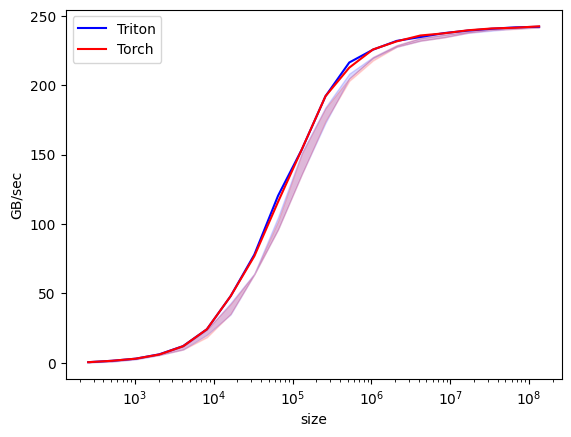

vector-add-performance:
           size      Triton       Torch
0         256.0    0.500000    0.497409
1         512.0    1.500000    1.500000
2        1024.0    3.023622    3.023622
3        2048.0    6.181087    6.047244
4        4096.0   12.094488   12.000000
5        8192.0   24.188975   24.188975
6       16384.0   48.000000   48.000000
7       32768.0   77.895404   76.800002
8       65536.0  120.323134  115.924529
9      131072.0  153.600004  153.600004
10     262144.0  192.000000  192.000000
11     524288.0  216.219070  212.514727
12    1048576.0  225.461425  225.597246
13    2097152.0  231.787557  231.439668
14    4194304.0  234.566765  235.677431
15    8388608.0  237.404478  237.234382
16   16777216.0  239.196571  239.422779
17   33554432.0  240.518391  240.736509
18   67108864.0  241.541973  241.249189
19  134217728.0  241.940576  242.269747


In [7]:
benchmark.run(print_data=True, show_plots=True)